In [39]:
import json

with open('train/similar_100.json', 'r') as file:
    similar = json.loads(file.read())

with open('train/mask_100.json', 'r') as file:
    mask = json.loads(file.read())
    
with open('train/random_100.json', 'r') as file:
    random = json.loads(file.read())
    
with open('train/mix_30_30_40.json', 'r') as file:
    mix = json.loads(file.read())

In [40]:
EPOCH_NUMBER = 100
SAMPLES_PER_EPOCH_TRAIN = len(similar['train_loss']) // EPOCH_NUMBER
SAMPLES_PER_EPOCH_TEST = len(similar['test_loss']) // EPOCH_NUMBER

In [41]:
def get_mean_by_epoch(
    data: dict,
    train_metrics = ['train_loss', 'train_acc'],
    test_metrics = ['test_loss', 'test_acc'],
):
    mean_data = {}
    for key in data.keys():
        if key in train_metrics:
            if len(data[key]) > SAMPLES_PER_EPOCH_TRAIN:
                mean_data[key] = [sum(data[key][i:i + SAMPLES_PER_EPOCH_TRAIN]) / SAMPLES_PER_EPOCH_TRAIN for i in range(0, len(data[key]), SAMPLES_PER_EPOCH_TRAIN)]
            else:
                mean_data[key] = data[key]
        if key in test_metrics:
            if len(data[key]) > SAMPLES_PER_EPOCH_TEST:
                mean_data[key] = [sum(data[key][i:i + SAMPLES_PER_EPOCH_TEST]) / SAMPLES_PER_EPOCH_TEST for i in range(0, len(data[key]), SAMPLES_PER_EPOCH_TEST)]
            else:
                mean_data[key] = data[key]
    return mean_data

mean_similar = get_mean_by_epoch(similar)
mean_mask = get_mean_by_epoch(mask)
mean_random = get_mean_by_epoch(random)
mean_mix = get_mean_by_epoch(mix)


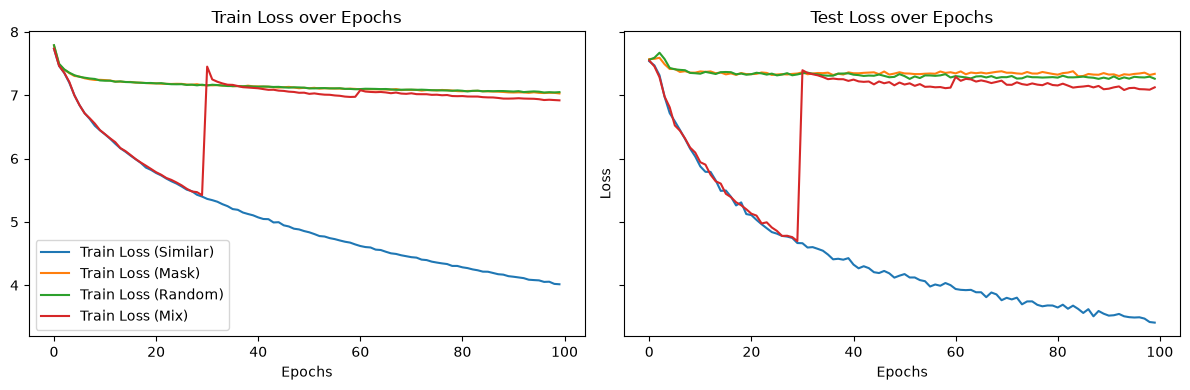

In [42]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

axes[0].plot(mean_similar['train_loss'], label='Train Loss (Similar)')
axes[0].plot(mean_mask['train_loss'], label='Train Loss (Mask)')
axes[0].plot(mean_random['train_loss'], label='Train Loss (Random)')
axes[0].plot(mean_mix['train_loss'], label='Train Loss (Mix)')
axes[0].set_title('Train Loss over Epochs')
axes[0].set_xlabel('Epochs')
axes[0].legend()

axes[1].plot(mean_similar['test_loss'], label='Test Loss (Similar)')
axes[1].plot(mean_mask['test_loss'], label='Test Loss (Mask)')
axes[1].plot(mean_random['test_loss'], label='Test Loss (Random)')
axes[1].plot(mean_mix['test_loss'], label='Test Loss (Mix)')
axes[1].set_title('Test Loss over Epochs')
axes[1].set_xlabel('Epochs')
axes[1].set_ylabel('Loss')
axes[0].legend()

plt.tight_layout()
plt.show()

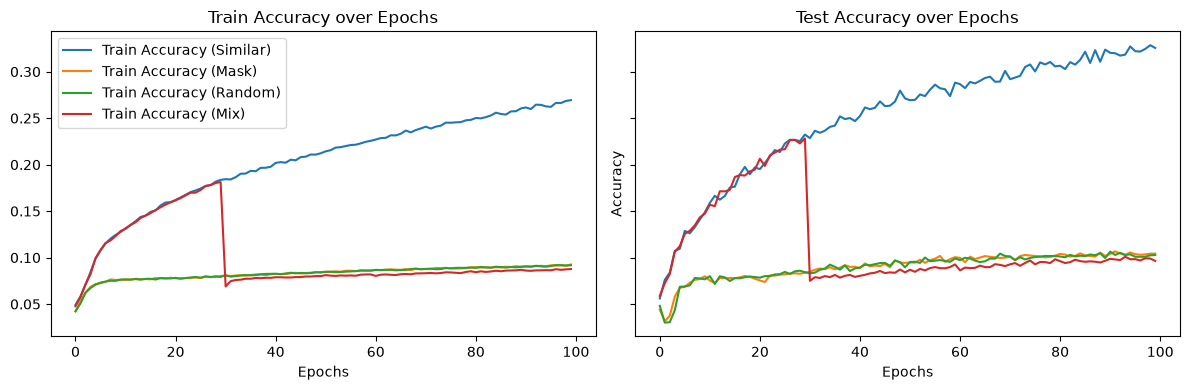

In [43]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

axes[0].plot(mean_similar['train_acc'], label='Train Accuracy (Similar)')
axes[0].plot(mean_mask['train_acc'], label='Train Accuracy (Mask)')
axes[0].plot(mean_random['train_acc'], label='Train Accuracy (Random)')
axes[0].plot(mean_mix['train_acc'], label='Train Accuracy (Mix)')
axes[0].set_title('Train Accuracy over Epochs')
axes[0].set_xlabel('Epochs')
axes[0].legend()

axes[1].plot(mean_similar['test_acc'], label='Test Accuracy (Similar)')
axes[1].plot(mean_mask['test_acc'], label='Test Accuracy (Mask)')
axes[1].plot(mean_random['test_acc'], label='Test Accuracy (Random)')
axes[1].plot(mean_mix['test_acc'], label='Test Accuracy (Mix)')
axes[1].set_title('Test Accuracy over Epochs')
axes[1].set_xlabel('Epochs')
axes[1].set_ylabel('Accuracy')
axes[0].legend()

plt.tight_layout()
plt.show()

In [54]:
import pandas as pd

paths = [
    'eval/evaluation_results_2.json',
    'eval/evaluation_results_5.json',
    'eval/evaluation_results_10.json',
    'eval/evaluation_results_20.json',
    'eval/evaluation_results_50.json'
]

df1 = pd.read_json('eval/evaluation_results_10.json')
df = pd.read_json('eval/evaluation_results_50.json')

In [55]:
def compare_models_by_method(df, corruption_method, corruption_rate, metrics = ['loss', 'accuracy', 'accuracy_denoising']):
    models = df.model.unique()
    df = df[(df['corruption_method'] == corruption_method) & (df['corruption_rate'] == corruption_rate)]
    fig, axes = plt.subplots(1, 3, figsize=(12, 4))
    fig.suptitle(f'Comparison of Models by {corruption_method.capitalize()} Corruption (Rate: {int(corruption_rate * 100)}%)')
    for i, metric in enumerate(metrics):
        model_names = [model.split('_')[0] if '_' in model else model for model in models]
        axes[i].bar(x=model_names, height=df[metric])
        axes[i].set_title(f'{metric.capitalize()}')

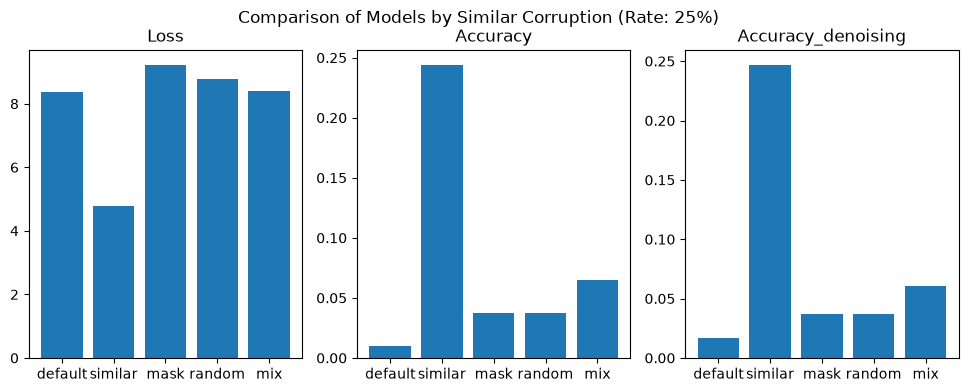

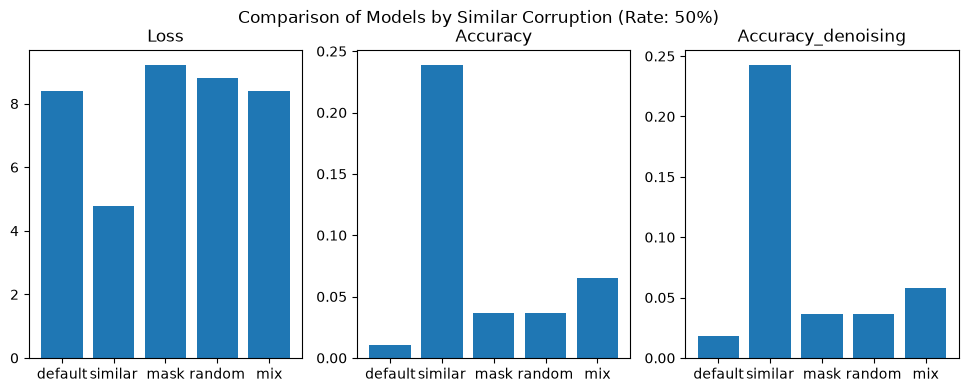

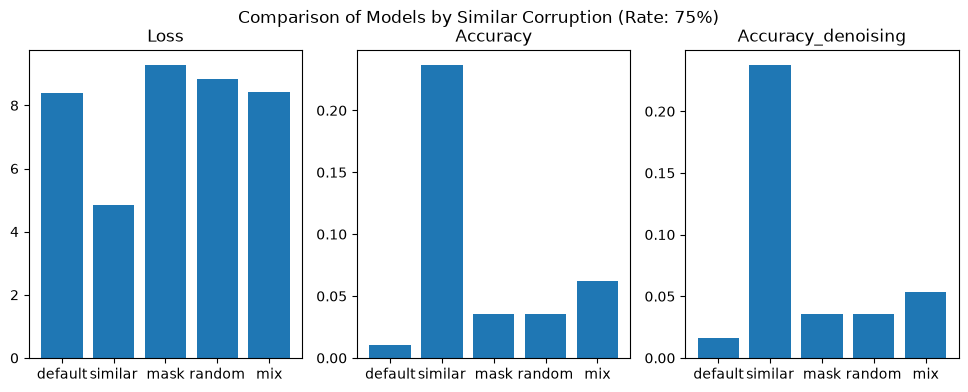

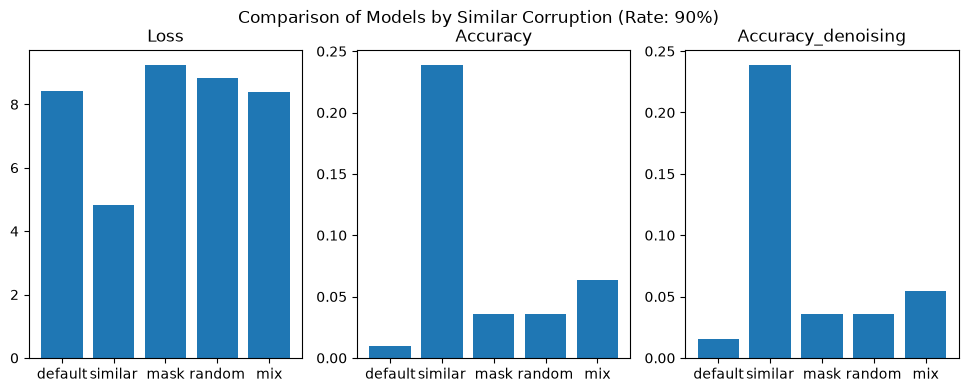

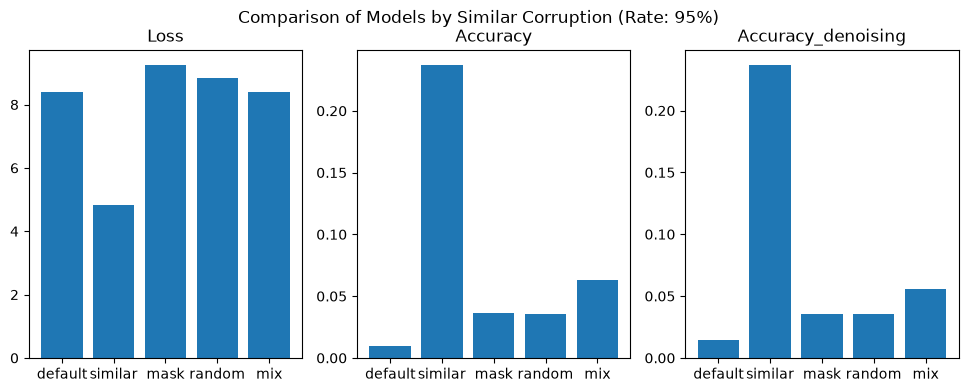

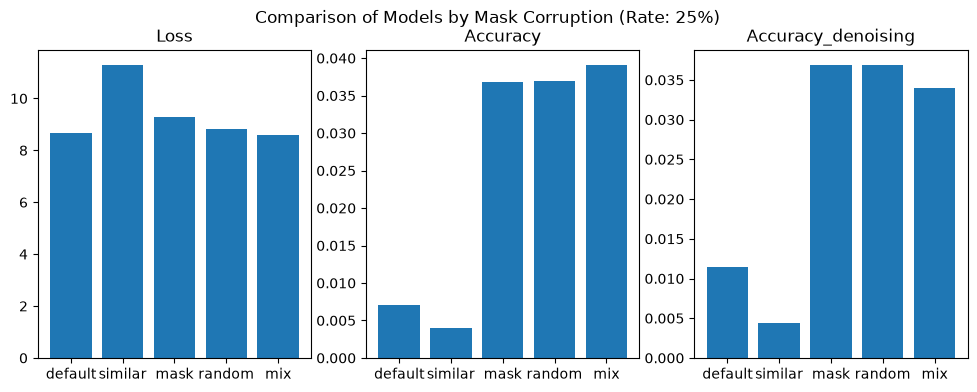

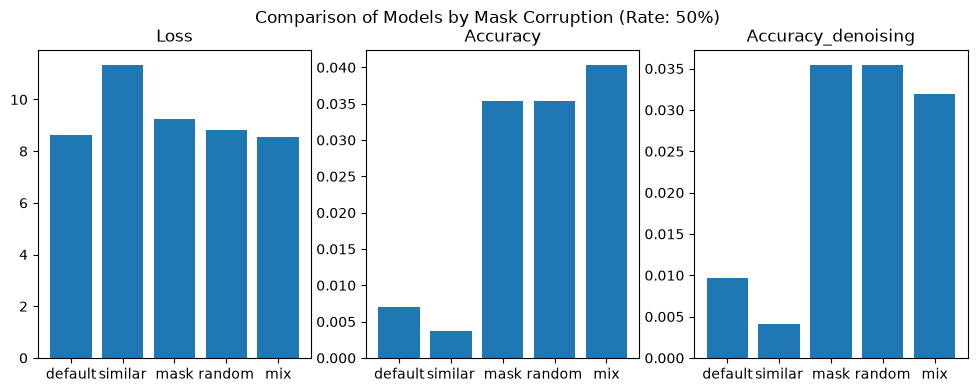

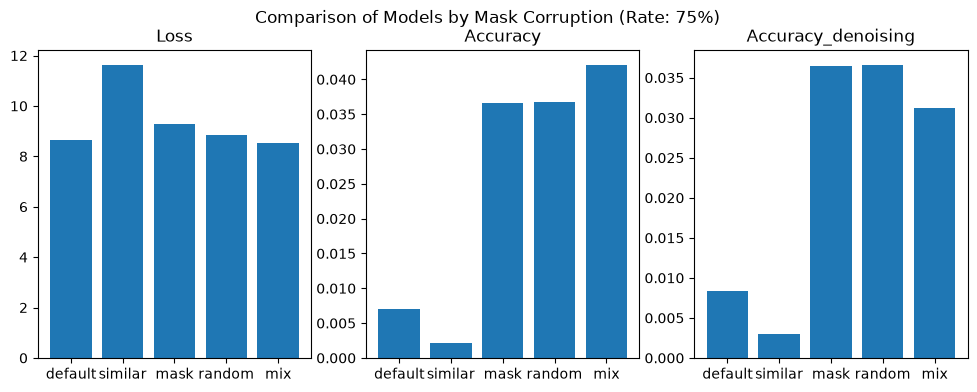

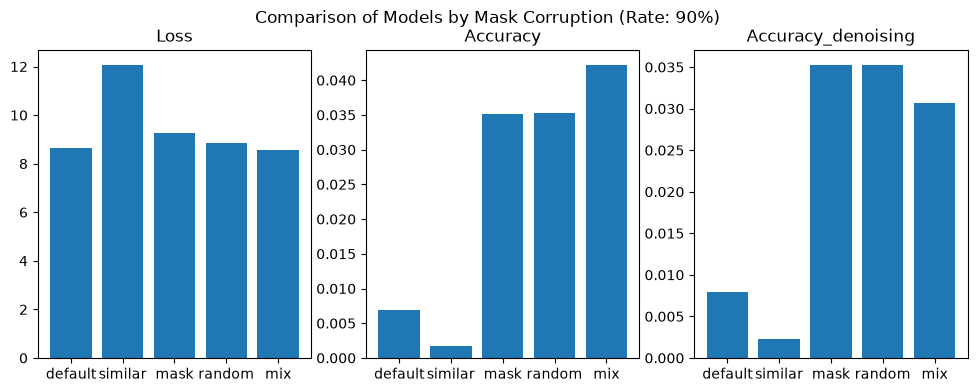

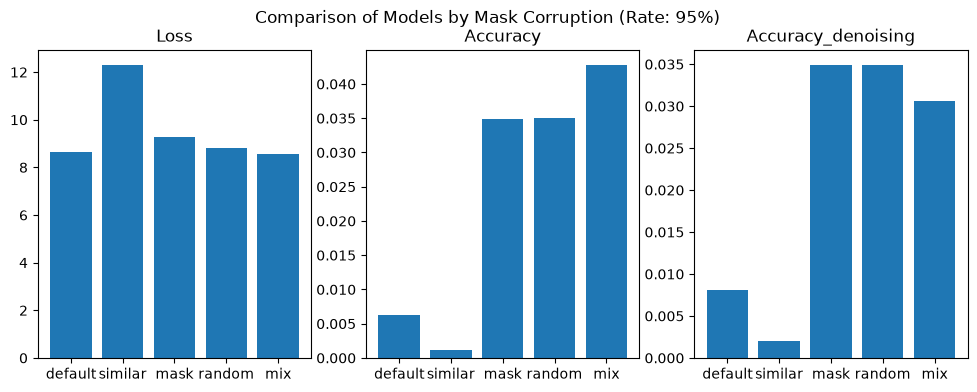

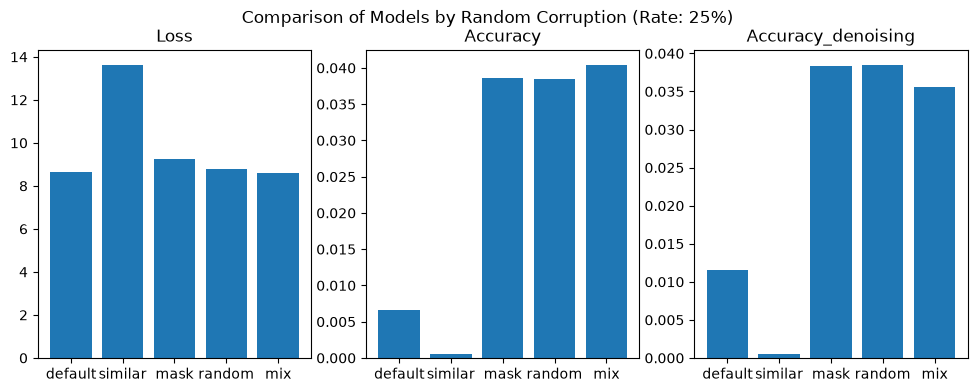

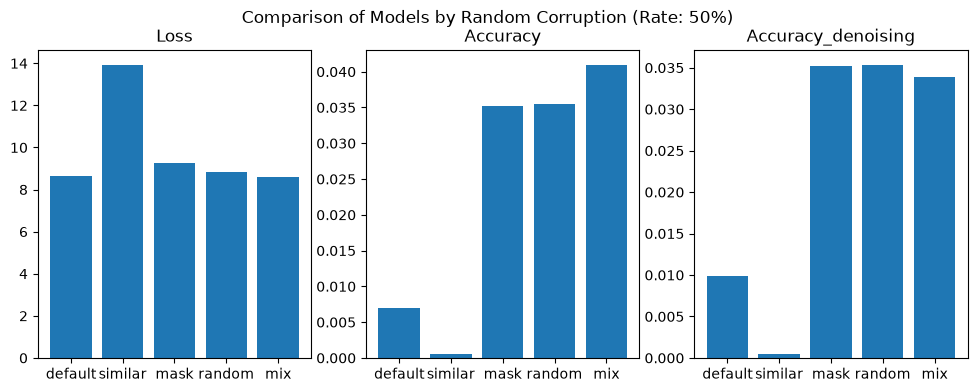

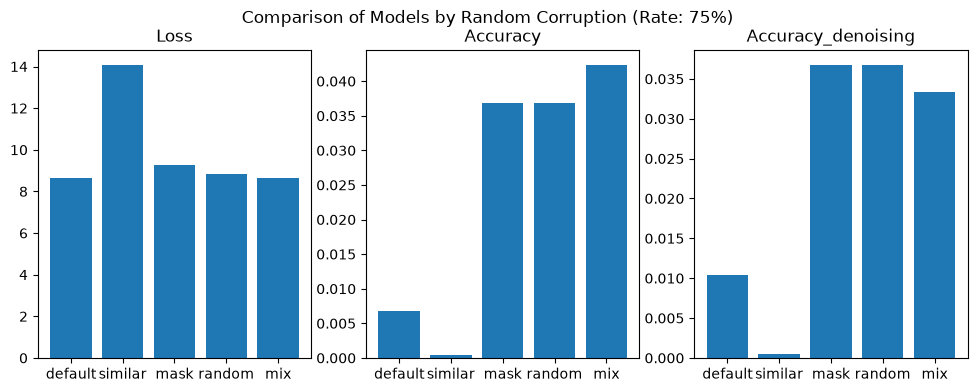

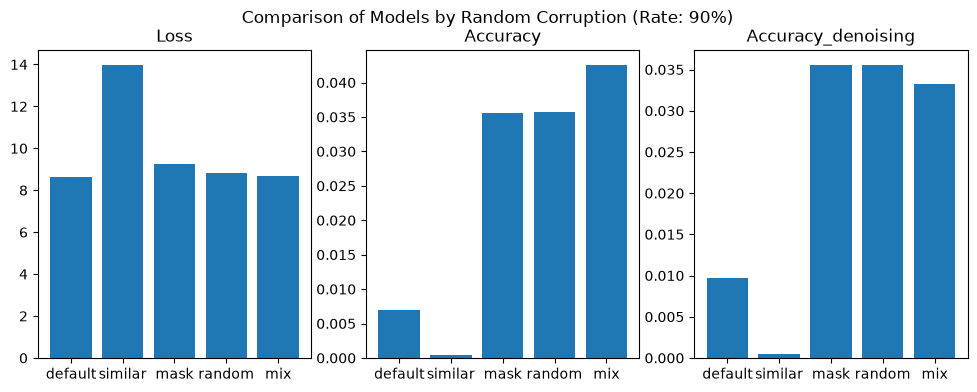

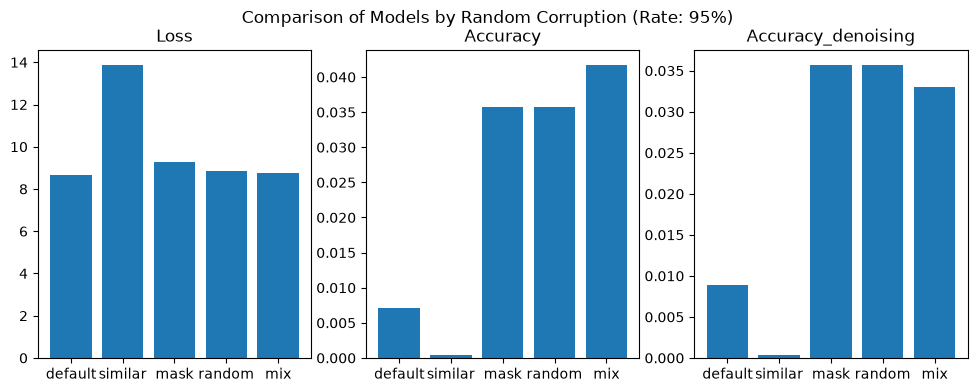

In [56]:
for corruption_method in df['corruption_method'].unique():
    for corruption_rate in df['corruption_rate'].unique():
        compare_models_by_method(df, corruption_method, corruption_rate)

Loaded 5 files and 375 rows.
Using 50 denoising iterations for the main matrix plots.


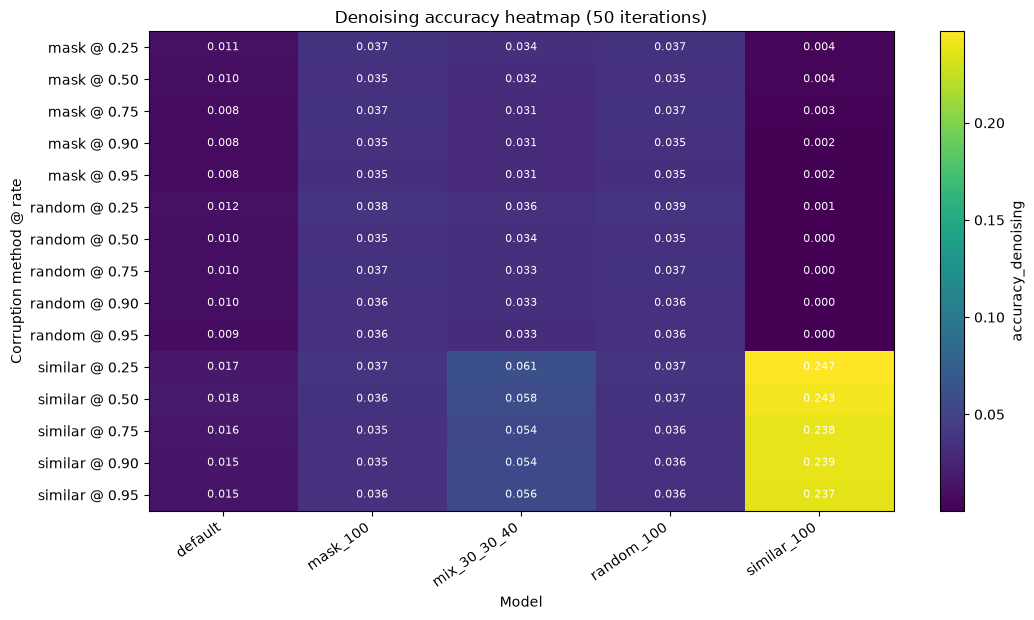

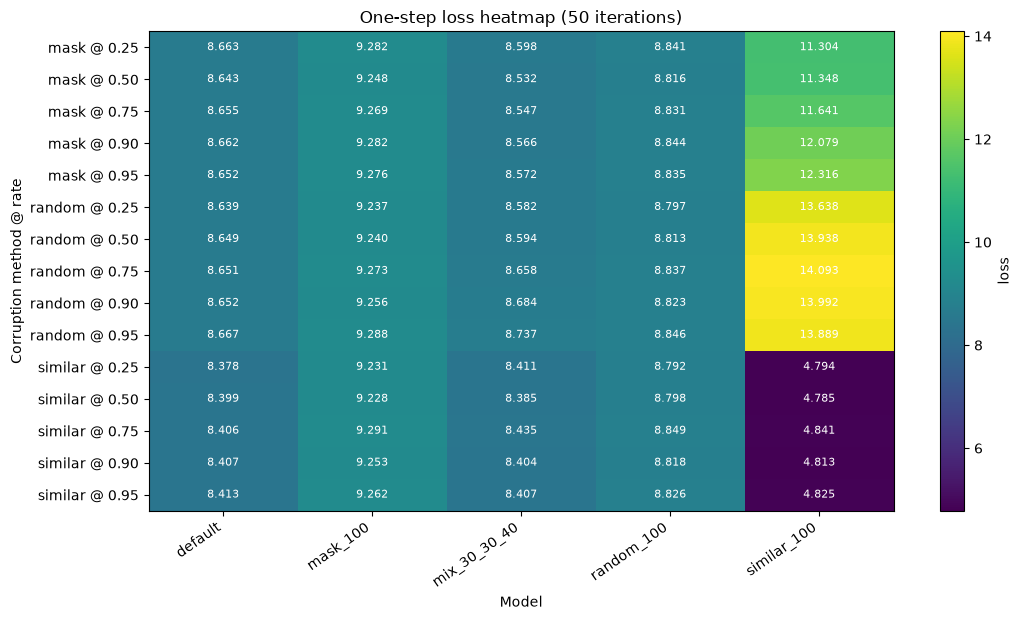

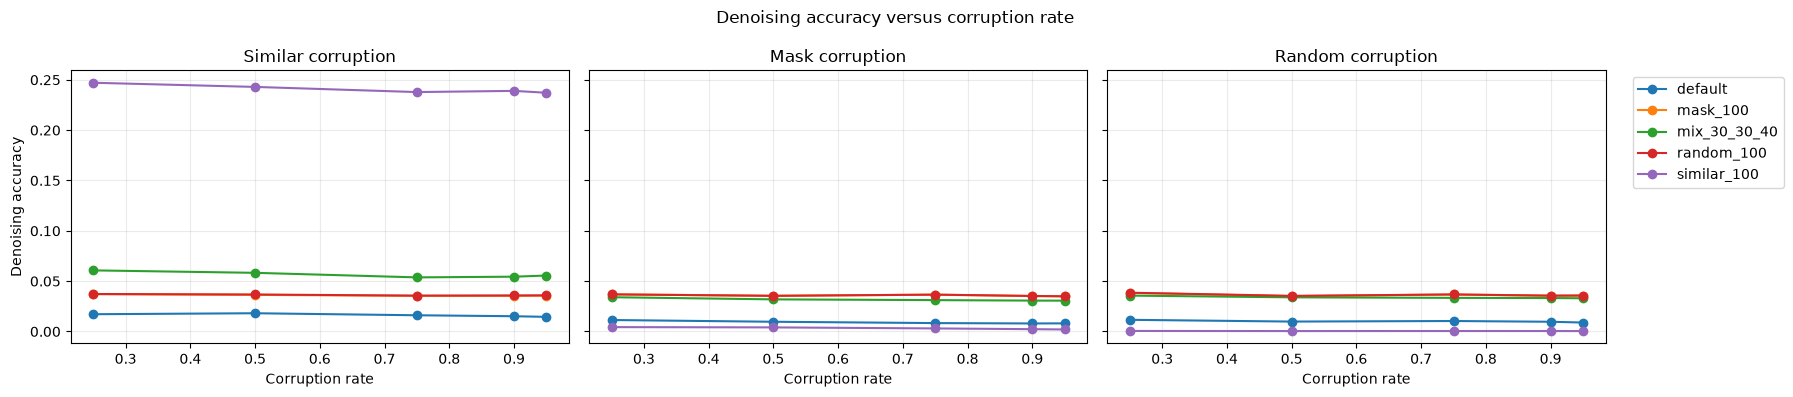

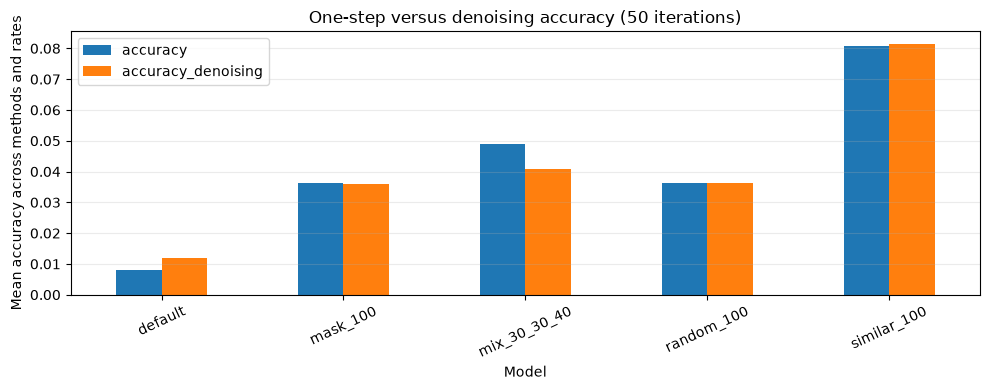

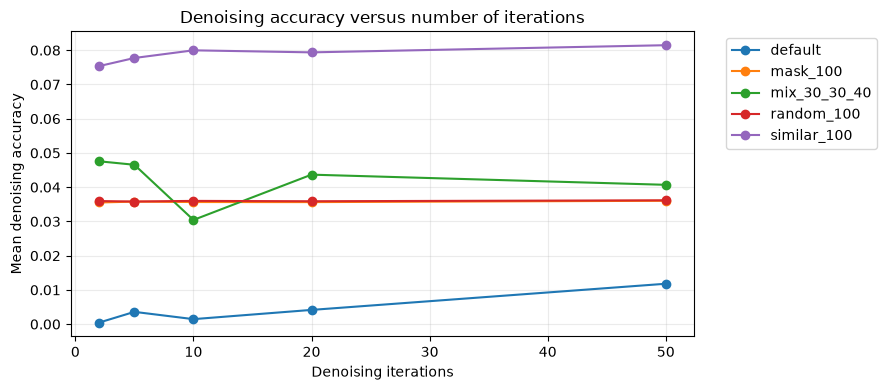

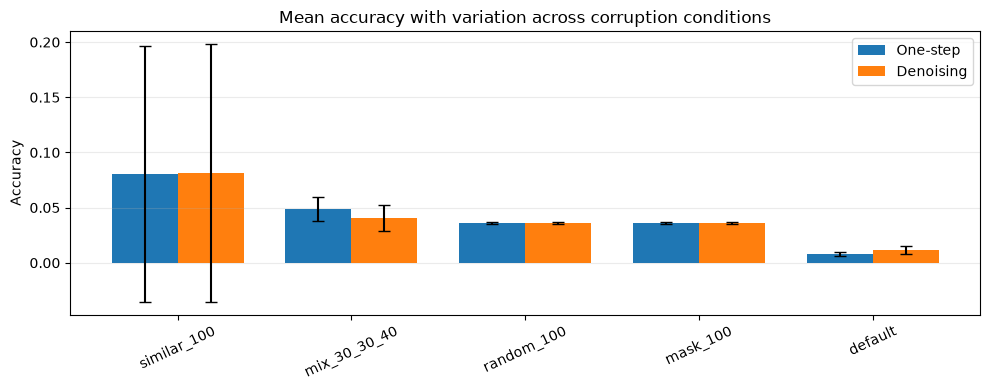

,mean_accuracy,std_accuracy,mean_denoising_accuracy,std_denoising_accuracy
model,,,,
similar_100,0.080777,0.116071,0.081470,0.116645
mix_30_30_40,0.048936,0.010964,0.040691,0.011783
random_100,0.036192,0.000938,0.036165,0.000948
mask_100,0.036140,0.000989,0.036032,0.000933
default,0.007941,0.001604,0.011796,0.003483


In [53]:
from pathlib import Path
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

folders = [Path('eval'), Path('results/eval'), Path('.')]
eval_files = sorted({path.resolve() for folder in folders if folder.exists() for path in folder.glob('evaluation_results_*.json')})
if not eval_files:
    raise FileNotFoundError('No evaluation_results_*.json files found.')

frames = []
for path in eval_files:
    current = pd.read_json(path)
    match = re.search(r'_([0-9]+)\.json$', path.name)
    filename_steps = int(match.group(1)) if match else 0
    if 'denoise_iterations' not in current:
        current['denoise_iterations'] = filename_steps
    current['source_file'] = path.name
    frames.append(current)
eval_df = pd.concat(frames, ignore_index=True)
latest_steps = eval_df['denoise_iterations'].max()
latest_df = eval_df[eval_df['denoise_iterations'] == latest_steps].copy()
print(f'Loaded {len(eval_files)} files and {len(eval_df)} rows.')
print(f'Using {latest_steps} denoising iterations for the main matrix plots.')

def plot_heatmap(data, value, title, fmt='.3f'):
    table = data.pivot_table(index=['corruption_method', 'corruption_rate'], columns='model', values=value)
    labels = [f'{method} @ {rate:.2f}' for method, rate in table.index]
    fig, ax = plt.subplots(figsize=(11, max(4, 0.42 * len(table))))
    image = ax.imshow(table.to_numpy(dtype=float), aspect='auto', cmap='viridis')
    ax.set_xticks(range(len(table.columns)), table.columns, rotation=35, ha='right')
    ax.set_yticks(range(len(labels)), labels)
    ax.set_title(title)
    ax.set_xlabel('Model')
    ax.set_ylabel('Corruption method @ rate')
    fig.colorbar(image, ax=ax, label=value)
    for row in range(table.shape[0]):
        for col in range(table.shape[1]):
            cell_value = table.iloc[row, col]
            if pd.notna(cell_value):
                ax.text(col, row, format(cell_value, fmt), ha='center', va='center', color='white', fontsize=8)
    plt.tight_layout()
    plt.show()

plot_heatmap(latest_df, 'accuracy_denoising', f'Denoising accuracy heatmap ({latest_steps} iterations)')
plot_heatmap(latest_df, 'loss', f'One-step loss heatmap ({latest_steps} iterations)')

methods = list(latest_df['corruption_method'].drop_duplicates())
fig, axes = plt.subplots(1, len(methods), figsize=(6 * len(methods), 4), sharey=True)
axes = np.atleast_1d(axes)
for ax, method in zip(axes, methods):
    subset = latest_df[latest_df['corruption_method'] == method]
    for model, group in subset.groupby('model'):
        group = group.sort_values('corruption_rate')
        ax.plot(group['corruption_rate'], group['accuracy_denoising'], marker='o', label=model)
    ax.set_title(f'{method.capitalize()} corruption')
    ax.set_xlabel('Corruption rate')
    ax.grid(alpha=0.25)
axes[0].set_ylabel('Denoising accuracy')
axes[-1].legend(bbox_to_anchor=(1.04, 1), loc='upper left')
fig.suptitle('Denoising accuracy versus corruption rate')
plt.tight_layout()
plt.show()

comparison = latest_df.groupby('model')[['accuracy', 'accuracy_denoising']].mean()
ax = comparison.plot(kind='bar', figsize=(10, 4), rot=25)
ax.set_title(f'One-step versus denoising accuracy ({latest_steps} iterations)')
ax.set_xlabel('Model')
ax.set_ylabel('Mean accuracy across methods and rates')
ax.grid(axis='y', alpha=0.25)
plt.tight_layout()
plt.show()

curve = eval_df.groupby(['denoise_iterations', 'model'])['accuracy_denoising'].mean().reset_index()
fig, ax = plt.subplots(figsize=(9, 4))
for model, group in curve.groupby('model'):
    group = group.sort_values('denoise_iterations')
    ax.plot(group['denoise_iterations'], group['accuracy_denoising'], marker='o', label=model)
ax.set_title('Denoising accuracy versus number of iterations')
ax.set_xlabel('Denoising iterations')
ax.set_ylabel('Mean denoising accuracy')
ax.grid(alpha=0.25)
ax.legend(bbox_to_anchor=(1.04, 1), loc='upper left')
plt.tight_layout()
plt.show()

# Error bars show variation across corruption conditions, not seed uncertainty.
summary = latest_df.groupby('model').agg(
    mean_accuracy=('accuracy', 'mean'),
    std_accuracy=('accuracy', 'std'),
    mean_denoising_accuracy=('accuracy_denoising', 'mean'),
    std_denoising_accuracy=('accuracy_denoising', 'std'),
).sort_values('mean_denoising_accuracy', ascending=False)
fig, ax = plt.subplots(figsize=(10, 4))
x = np.arange(len(summary))
width = 0.38
ax.bar(x - width / 2, summary['mean_accuracy'], width, yerr=summary['std_accuracy'], capsize=4, label='One-step')
ax.bar(x + width / 2, summary['mean_denoising_accuracy'], width, yerr=summary['std_denoising_accuracy'], capsize=4, label='Denoising')
ax.set_xticks(x, summary.index, rotation=25)
ax.set_ylabel('Accuracy')
ax.set_title('Mean accuracy with variation across corruption conditions')
ax.grid(axis='y', alpha=0.25)
ax.legend()
plt.tight_layout()
plt.show()

summary
